# ltr_wnl demo

This notebook demonstrates the core functionality of the `ltr_wnl` (Learning to Rank with Noisy Labels) package.

## Summary

This demo shows:

1. **Basic Usage**: How to set up and run a ranking simulation
2. **Noise Uncertainty (φ)**: Effect of concentration parameter on sample complexity
3. **Mean Error Rate (μ)**: Effect of error rate on ranking accuracy and sample requirements
4. **Algorithm Comparison**: Comparing Borda Count, Plackett-Luce MLE, and Rank Centrality
5. **Graph Visualizations**: Network view of comparisons and win rate matrices
6. **Noise Model**: How φ controls the variance of error rates

### Key Insights

- **μ dominates φ**: Mean error rate (μ) has much stronger impact on performance than concentration (φ)
- **50% threshold**: Pairwise ranking breaks down at 50% error rate (random coin flip)
- **Statistical methods win**: Plackett-Luce and Rank Centrality outperform simple Borda Count
- **Sample complexity**: More comparisons can partially compensate for lower-precision judges

In [1]:
# Auto-reload modules for development
%load_ext autoreload
%autoreload 2

In [2]:
# Setup Python path to find ltr_wnl module
import sys
from pathlib import Path

# Add parent directory to path
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import ltr_wnl components using namespace imports
from ltr_wnl import noise, ground_truth, ranking, sampling, simulation, metrics

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All imports successful!")

✓ All imports successful!


## 1. Basic Example: Ranking 10 Items

Let's start with a simple example: ranking 10 items using noisy pairwise comparisons.

In [6]:
# Setup
N_ITEMS = 10
N_COMPARISONS = 30
RANDOM_SEED = 42

# Create noise model (10% average error rate, moderate concentration)
noise_model = noise.BetaNoiseModel(mu=0.1, phi=10.0)

# Create simulation runner
runner = simulation.SimulationRunner(
    n_items=N_ITEMS,
    noise_model=noise_model,
    ranker=ranking.BordaCountRanker(),
    sampling_strategy=sampling.RandomSampling()
)

# Run simulation
results = runner.run_trial(
    n_comparisons=N_COMPARISONS,
    random_state=RANDOM_SEED
)

print("="*60)
print("SIMULATION RESULTS")
print("="*60)
print(f"Number of items: {N_ITEMS}")
print(f"Number of comparisons: {N_COMPARISONS}")
print(f"Noise model: Beta(mu={noise_model.mu}, phi={noise_model.phi})")
print()
print(f"True ranking:      {results['true_ranking']}")
print(f"Estimated ranking: {results['estimated_ranking']}")
print()
print(f"Kendall's tau distance: {results['kendall_distance']} inversions")
print(f"Normalized distance:    {results['normalized_kendall']:.3f}")
print(f"Rank correlation:       {results['rank_correlation']:.3f}")

print("="*60)

SIMULATION RESULTS
Number of items: 10
Number of comparisons: 30
Noise model: Beta(mu=0.1, phi=10.0)

True ranking:      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Estimated ranking: [1, 4, 2, 8, 5, 3, 6, 0, 9, 7]

Kendall's tau distance: 15 inversions
Normalized distance:    0.333
Rank correlation:       0.430


## 2. Understanding the Noise Model

Let's visualize what the Beta noise model actually does.

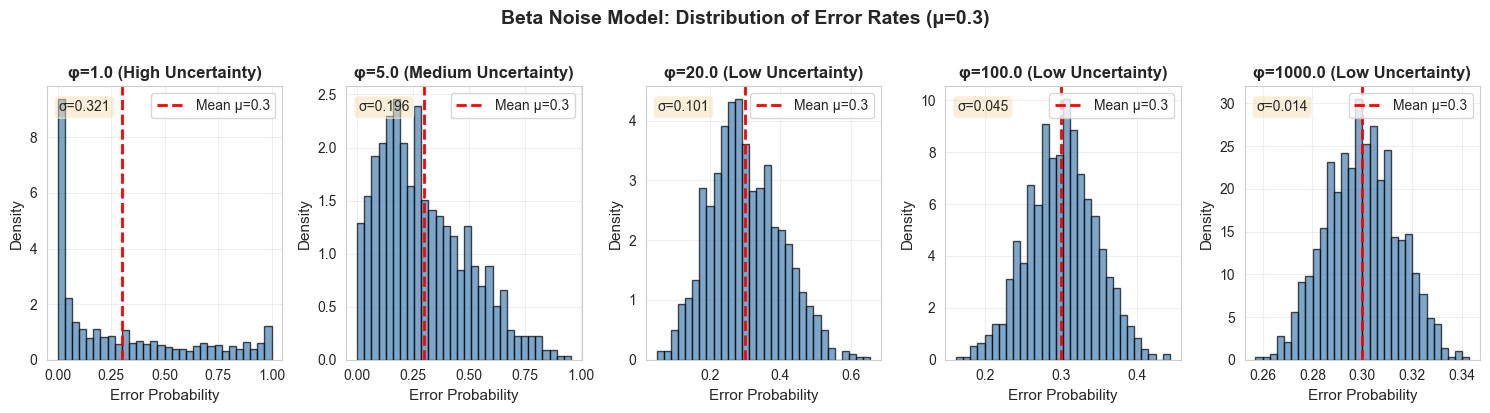


📊 Interpretation:
   • Low φ: Error rates vary widely (high variance) → harder to learn
   • High φ: Error rates clustered near mean (low variance) → easier to learn


In [46]:
# Sample error rates from different noise models
n_samples = 1000
mu = 0.3
phi_values = [1.0, 5.0, 20.0, 100., 1000.]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, phi in enumerate(phi_values):
    noise_model = noise.BetaNoiseModel(mu=mu, phi=phi)
    
    # Sample error rates
    error_rates = [noise_model.sample_error_rate() for _ in range(n_samples)]
    
    # Plot histogram
    axes[i].hist(error_rates, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i].axvline(mu, color='red', linestyle='--', linewidth=2, label=f'Mean μ={mu}')
    axes[i].set_xlabel('Error Probability', fontsize=11)
    axes[i].set_ylabel('Density', fontsize=11)
    axes[i].set_title(f'φ={phi} ({"High" if phi < 3 else "Medium" if phi < 15 else "Low"} Uncertainty)', fontsize=12, fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Add std dev annotation
    std_dev = np.std(error_rates)
    axes[i].text(0.05, 0.95, f'σ={std_dev:.3f}', 
                transform=axes[i].transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=10)

plt.suptitle(f'Beta Noise Model: Distribution of Error Rates (μ={mu})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   • Low φ: Error rates vary widely (high variance) → harder to learn")
print("   • High φ: Error rates clustered near mean (low variance) → easier to learn")

## 3. Effect of Noise Uncertainty (φ parameter)

The key research question: **Does uncertainty in noise rates affect sample complexity?**

We'll compare:
- **Low φ (high uncertainty)**: Error rates vary widely for each comparison
- **High φ (low uncertainty)**: Error rates are consistently near the mean

In [47]:
# Parameters
N_ITEMS = 100
MU = 0.2  # Mean error rate
SAMPLE_SIZES = np.linspace(100, 3000, 30, dtype=int)
N_TRIALS = 20  # Number of trials per condition

In [32]:
PHI_VALUES = [1.0, 5.0, 20.0, 100., 1000.]  # Low, medium, high concentration

print("Running experiment...")
print(f"Items: {N_ITEMS}, Trials per condition: {N_TRIALS}")
print(f"Phi values: {PHI_VALUES}")
print(f"Sample sizes: {SAMPLE_SIZES[0]} to {SAMPLE_SIZES[-1]}")

# Store results
results_by_phi = {}

for phi in PHI_VALUES:
    print(f"\n  Testing φ={phi}...")
    avg_errors = []
    
    for S in SAMPLE_SIZES:
        trial_errors = []
        
        # Run multiple trials
        for trial in range(N_TRIALS):
            runner = simulation.SimulationRunner(
                n_items=N_ITEMS,
                noise_model=noise.BetaNoiseModel(mu=MU, phi=phi),
                ranker=ranking.BordaCountRanker(),
                sampling_strategy=sampling.RandomSampling()
            )
            
            result = runner.run_trial(
                n_comparisons=S,
                random_state=trial * 1000 + int(phi * 100)
            )
            
            trial_errors.append(result['normalized_kendall'])
        
        avg_errors.append(np.mean(trial_errors))
    
    results_by_phi[phi] = avg_errors
    print(f"    ✓ Done")

print("\n✓ Experiment complete!")

Running experiment...
Items: 100, Trials per condition: 20
Phi values: [1.0, 5.0, 20.0, 100.0, 1000.0]
Sample sizes: 100 to 3000

  Testing φ=1.0...
    ✓ Done

  Testing φ=5.0...
    ✓ Done

  Testing φ=20.0...
    ✓ Done

  Testing φ=100.0...
    ✓ Done

  Testing φ=1000.0...
    ✓ Done

✓ Experiment complete!


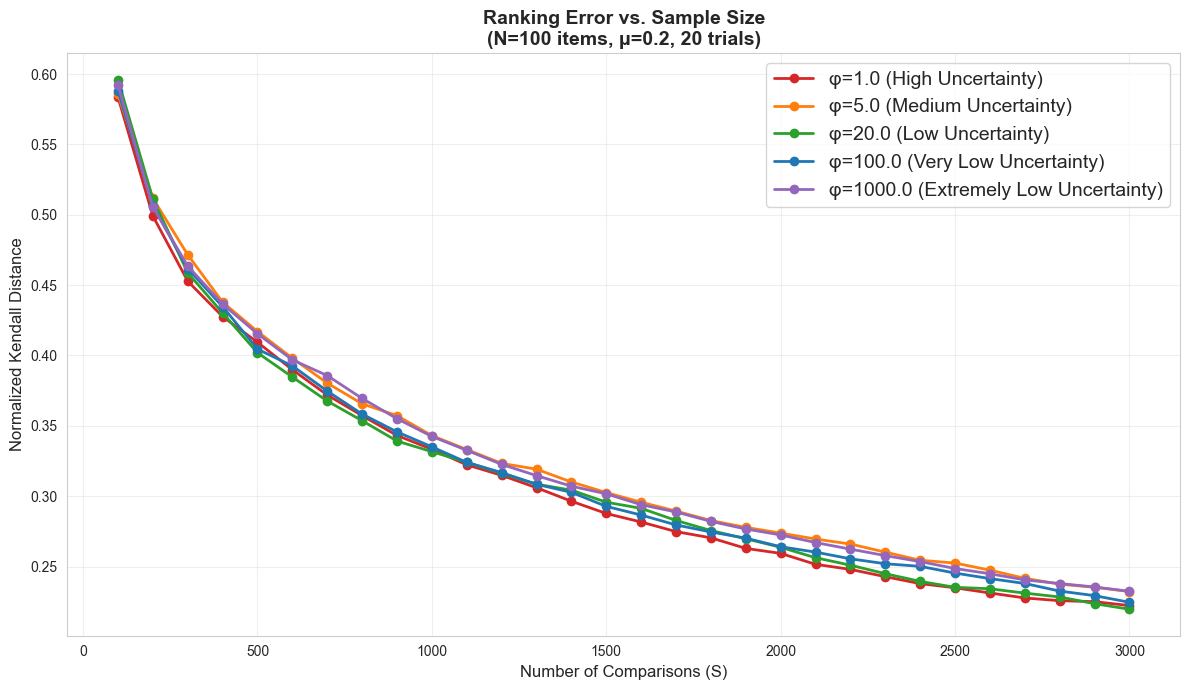

In [33]:
# Plot results
plt.figure(figsize=(12, 7))

colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
labels = [
    f'φ={PHI_VALUES[0]:.1f} (High Uncertainty)',
    f'φ={PHI_VALUES[1]:.1f} (Medium Uncertainty)',
    f'φ={PHI_VALUES[2]:.1f} (Low Uncertainty)',
    f'φ={PHI_VALUES[3]:.1f} (Very Low Uncertainty)',
    f'φ={PHI_VALUES[4]:.1f} (Extremely Low Uncertainty)'
]

for i, phi in enumerate(PHI_VALUES):
    plt.plot(
        SAMPLE_SIZES,
        results_by_phi[phi],
        marker='o',
        linewidth=2,
        markersize=6,
        color=colors[i],
        label=labels[i]
    )

plt.xlabel('Number of Comparisons (S)', fontsize=12)
plt.ylabel('Normalized Kendall Distance', fontsize=12)
plt.title(f'Ranking Error vs. Sample Size\n(N={N_ITEMS} items, μ={MU}, {N_TRIALS} trials)', fontsize=14, fontweight='bold')
plt.legend(fontsize=14, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



📊 Key Observation:


φ has surprisingly little impact. Very different error rate variances (φ=1 vs φ=1000) lead to nearly identical performance curves is interesting. If anything it appears that more variation in error rates, gives better (!) results.

That might be some asymmetry in the benefit of being right on the comparison: being more likely right sometimes, more than outweighs being off completely other times.

## 3b. Effect of Mean Error Rate (μ parameter)

**Alternative experiment**: How does the mean error rate affect ranking accuracy when noise uncertainty is fixed?

We'll compare different values of μ while keeping φ constant.

In [19]:
PHI = 10.0
MU_VALUES = [0.01, 0.05, 0.1, 0.25, 0.4, 0.5]  # Different mean error rates

print("Running experiment with varying μ...")
print(f"Items: {N_ITEMS}, Trials per condition: {N_TRIALS}")
print(f"Fixed φ: {PHI}")
print(f"μ values: {MU_VALUES}")
print(f"Sample sizes: {SAMPLE_SIZES[0]} to {SAMPLE_SIZES[-1]}")

# Store results
results_by_mu = {}

for mu in MU_VALUES:
    print(f"\n  Testing μ={mu}...")
    avg_errors = []
    
    for S in SAMPLE_SIZES:
        trial_errors = []
        
        # Run multiple trials
        for trial in range(N_TRIALS):
            runner = simulation.SimulationRunner(
                n_items=N_ITEMS,
                noise_model=noise.BetaNoiseModel(mu=mu, phi=PHI),
                ranker=ranking.BordaCountRanker(),
                sampling_strategy=sampling.RandomSampling()
            )
            
            result = runner.run_trial(
                n_comparisons=S,
                random_state=trial * 1000 + int(mu * 1000)
            )
            
            trial_errors.append(result['normalized_kendall'])
        
        avg_errors.append(np.mean(trial_errors))
    
    results_by_mu[mu] = avg_errors
    print(f"    ✓ Done")

print("\n✓ Experiment complete!")

Running experiment with varying μ...
Items: 100, Trials per condition: 20
Fixed φ: 10.0
μ values: [0.01, 0.05, 0.1, 0.25, 0.4, 0.5]
Sample sizes: 100 to 3000

  Testing μ=0.01...
    ✓ Done

  Testing μ=0.05...
    ✓ Done

  Testing μ=0.1...
    ✓ Done

  Testing μ=0.25...
    ✓ Done

  Testing μ=0.4...
    ✓ Done

  Testing μ=0.5...
    ✓ Done

✓ Experiment complete!


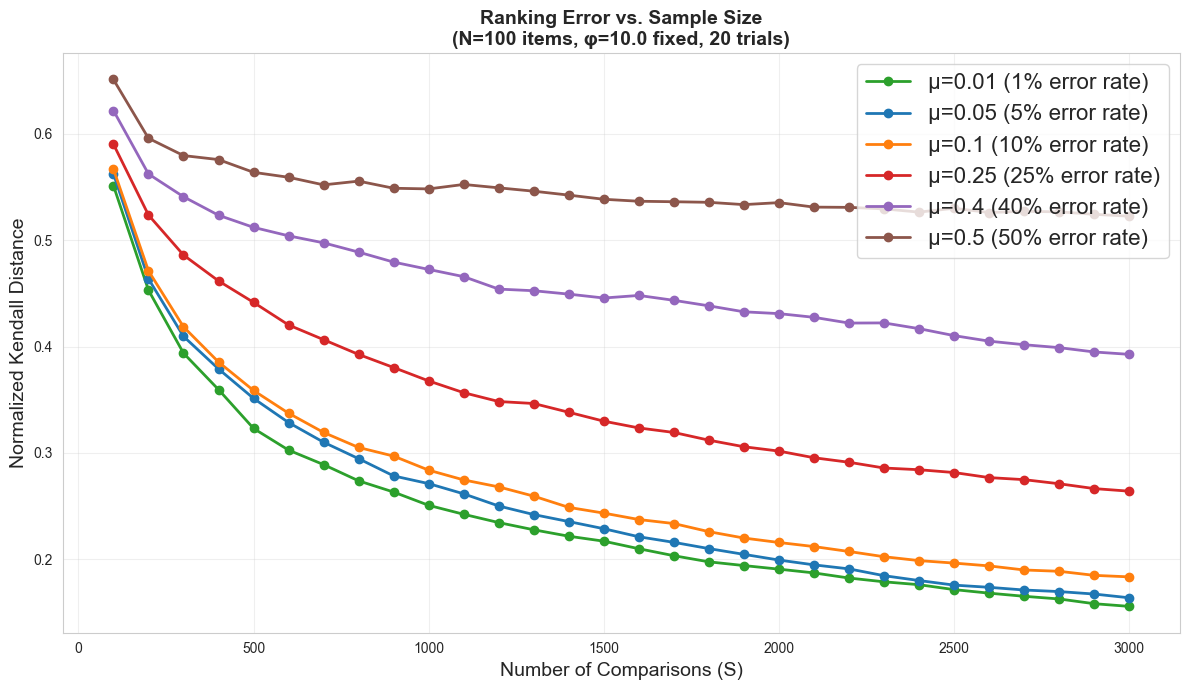

In [20]:
# Plot results
plt.figure(figsize=(12, 7))

colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd', '#8c564b']
labels = [f'μ={mu} ({int(mu*100)}% error rate)' for mu in MU_VALUES]

for i, mu in enumerate(MU_VALUES):
    plt.plot(
        SAMPLE_SIZES,
        results_by_mu[mu],
        marker='o',
        linewidth=2,
        markersize=6,
        color=colors[i],
        label=labels[i]
    )

plt.xlabel('Number of Comparisons (S)', fontsize=14)
plt.ylabel('Normalized Kendall Distance', fontsize=14)
plt.title(f'Ranking Error vs. Sample Size\n(N={N_ITEMS} items, φ={PHI} fixed, {N_TRIALS} trials)', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3c: Performance as a function of mu and phi

AUC by φ (concentration parameter):
  φ=    1.0: AUC=     0.3
  φ=    5.0: AUC=     0.3
  φ=   20.0: AUC=     0.3
  φ=  100.0: AUC=     0.3
  φ= 1000.0: AUC=     0.3

AUC by μ (mean error rate):
  μ=0.01: AUC=     0.2
  μ=0.05: AUC=     0.2
  μ=0.10: AUC=     0.3
  μ=0.25: AUC=     0.3
  μ=0.40: AUC=     0.4
  μ=0.50: AUC=     0.5


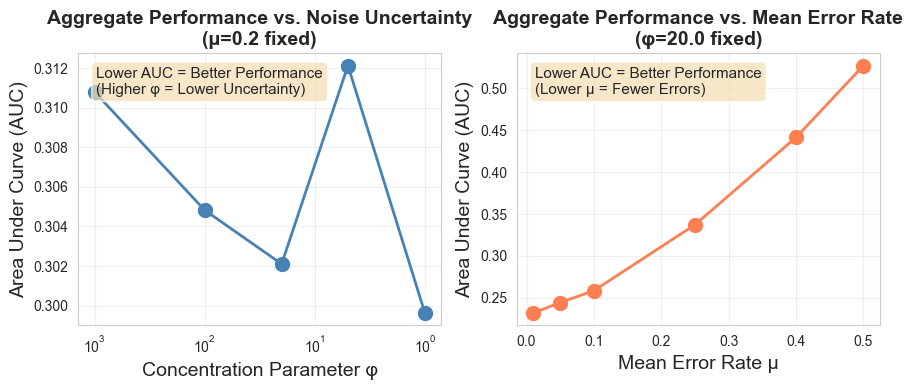


RELATIVE PERFORMANCE DIFFERENCES

φ variation (1.0 to 1000.0):
  AUC range: 0.3 to 0.3
  Relative difference: 4.2%

μ variation (0.01 to 0.5):
  AUC range: 0.2 to 0.5
  Relative difference: 127.6%

📊 Key Finding: μ has 30.6x stronger impact than φ on sample efficiency


In [50]:
# Compute AUC for each condition using trapezoidal integration
from scipy.integrate import trapezoid
_STEP_SIZE = SAMPLE_SIZES[1] - SAMPLE_SIZES[0]
# AUC for varying phi (from experiment in section 2)
auc_by_phi = {}
for phi in PHI_VALUES:
    auc = trapezoid(results_by_phi[phi], SAMPLE_SIZES)
    auc_by_phi[phi] = auc / len(results_by_phi[phi]) / _STEP_SIZE

# AUC for varying mu (from experiment in section 2b)
auc_by_mu = {}
for mu in MU_VALUES:
    auc = trapezoid(results_by_mu[mu], SAMPLE_SIZES)
    auc_by_mu[mu] = auc / len(results_by_mu[mu]) / _STEP_SIZE

print("AUC by φ (concentration parameter):")
for phi, auc in auc_by_phi.items():
    print(f"  φ={phi:7.1f}: AUC={auc:8.1f}")

print("\nAUC by μ (mean error rate):")
for mu, auc in auc_by_mu.items():
    print(f"  μ={mu:4.2f}: AUC={auc:8.1f}")

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot 1: AUC vs φ
axes[0].plot(list(auc_by_phi.keys()), list(auc_by_phi.values()), 
             marker='o', linewidth=2, markersize=10, color='steelblue')
axes[0].set_xlabel('Concentration Parameter φ', fontsize=14)
axes[0].set_ylabel('Area Under Curve (AUC)', fontsize=14)
axes[0].set_title(f'Aggregate Performance vs. Noise Uncertainty\n(μ={MU} fixed)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()  # Higher φ = lower uncertainty, so invert for intuitive reading

# Add text annotation
axes[0].text(0.05, 0.95, 'Lower AUC = Better Performance\n(Higher φ = Lower Uncertainty)', 
            transform=axes[0].transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
            fontsize=11)

# Plot 2: AUC vs μ
axes[1].plot(list(auc_by_mu.keys()), list(auc_by_mu.values()), 
             marker='o', linewidth=2, markersize=10, color='coral')
axes[1].set_xlabel('Mean Error Rate μ', fontsize=14)
axes[1].set_ylabel('Area Under Curve (AUC)', fontsize=14)
axes[1].set_title(f'Aggregate Performance vs. Mean Error Rate\n(φ={PHI} fixed)', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add text annotation
axes[1].text(0.05, 0.95, 'Lower AUC = Better Performance\n(Lower μ = Fewer Errors)', 
            transform=axes[1].transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
            fontsize=11)

plt.tight_layout()
plt.show()

# Compute relative differences
print("\n" + "="*60)
print("RELATIVE PERFORMANCE DIFFERENCES")
print("="*60)

# φ effect (compare min to max)
phi_min, phi_max = min(auc_by_phi.values()), max(auc_by_phi.values())
phi_diff_pct = (phi_max - phi_min) / phi_min * 100
print(f"\nφ variation (1.0 to 1000.0):")
print(f"  AUC range: {phi_min:.1f} to {phi_max:.1f}")
print(f"  Relative difference: {phi_diff_pct:.1f}%")

# μ effect (compare 0.01 to 0.5)
mu_min, mu_max = auc_by_mu[0.01], auc_by_mu[0.5]
mu_diff_pct = (mu_max - mu_min) / mu_min * 100
print(f"\nμ variation (0.01 to 0.5):")
print(f"  AUC range: {mu_min:.1f} to {mu_max:.1f}")
print(f"  Relative difference: {mu_diff_pct:.1f}%")

print(f"\n📊 Key Finding: μ has {mu_diff_pct/phi_diff_pct:.1f}x stronger impact than φ on sample efficiency")
print("="*60)

## 4. Comparing Ranking Algorithms

Let's compare Borda Count with Plackett-Luce MLE (via the `choix` library).

In [121]:
# Try to import choix rankers
from ltr_wnl import ranking

In [ ]:
# Parameters
N_ITEMS = 20
PHI = 20.0  # Moderate uncertainty
MU = 0.2
SAMPLE_SIZES = np.linspace(20, 200, 11, dtype=int)
N_TRIALS = 20

rankers = {
    'Borda Count': ranking.BordaCountRanker(),
    'Plackett-Luce MLE': ranking.PlackettLuceRanker(),
    'Rank Centrality': ranking.RankCentralityRanker(),
    'Page Rank': ranking.PageRankRanker(),
}

print(f"Comparing rankers on {N_ITEMS} items...")

results_by_ranker = {}

for ranker_name, ranker in rankers.items():
    print(f"\n  Testing {ranker_name}...")
    avg_errors = []
    
    for S in SAMPLE_SIZES:
        trial_errors = []
        
        for trial in range(N_TRIALS):
            runner = simulation.SimulationRunner(
                n_items=N_ITEMS,
                noise_model=noise.BetaNoiseModel(mu=MU, phi=PHI),
                ranker=ranker,
                sampling_strategy=sampling.RandomSampling()
            )
            
            try:
                result = runner.run_trial(
                    n_comparisons=S,
                    random_state=trial * 1000
                )
            except Exception as e:
                continue
            
            trial_errors.append(result['normalized_kendall'])
        
        avg_errors.append(np.mean(trial_errors))
    
    results_by_ranker[ranker_name] = avg_errors
    print(f"    ✓ Done")

print("\n✓ Ranker comparison complete!")


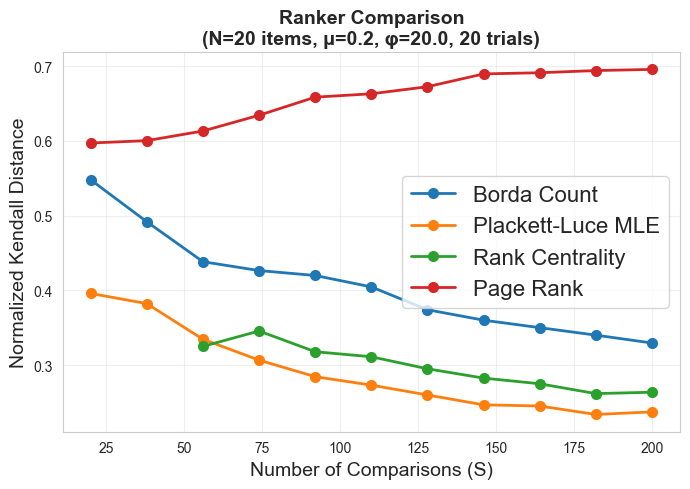

In [39]:
plt.figure(figsize=(7, 5))

for ranker_name, errors in results_by_ranker.items():
    plt.plot(
        SAMPLE_SIZES,
        errors,
        marker='o',
        linewidth=2,
        markersize=7,
        label=ranker_name
    )

plt.xlabel('Number of Comparisons (S)', fontsize=14)
plt.ylabel('Normalized Kendall Distance', fontsize=14)
plt.title(f'Ranker Comparison\n(N={N_ITEMS} items, μ={MU}, φ={PHI}, {N_TRIALS} trials)', fontsize=14, fontweight='bold')
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

📊 Key Observation:
   
Statistical methods (Plackett-Luce, Rank Centrality) are more efficient than Borda Count (achieve lower error with the same number of comparisons)

## 4b. Visualizing the Comparison Graph

Let's visualize the pairwise comparison network as a directed graph where edges represent comparisons and edge weights represent win rates.

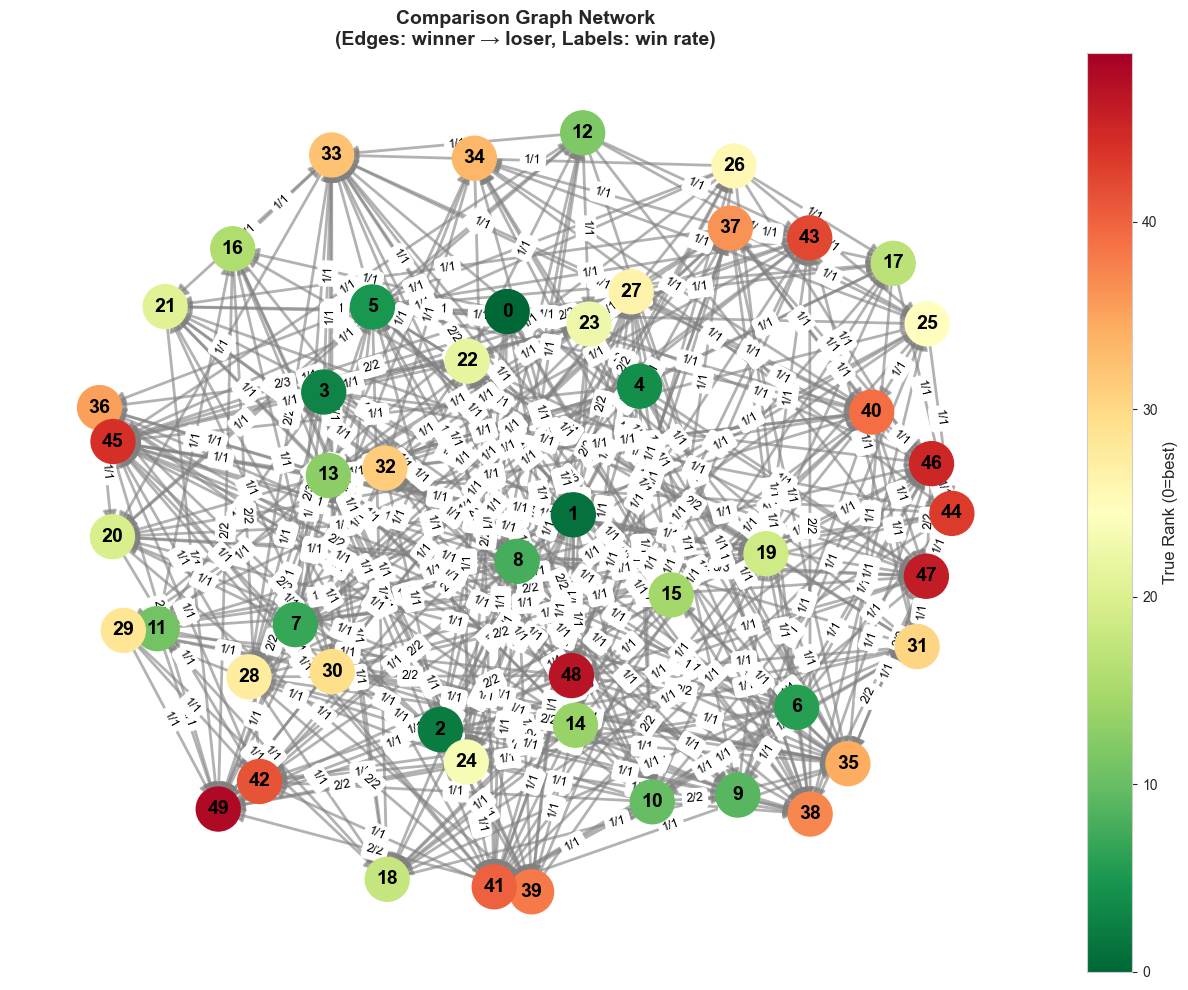


True ranking: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Graph edges: 391


In [40]:
import networkx as nx

# Run a small simulation to visualize
N_ITEMS_VIZ = 50
N_COMPARISONS_VIZ = 500

runner_viz = simulation.SimulationRunner(
    n_items=N_ITEMS_VIZ,
    noise_model=noise.BetaNoiseModel(mu=0.1, phi=10.0),
    ranker=ranking.BordaCountRanker(),
    sampling_strategy=sampling.RandomSampling()
)

results_viz = runner_viz.run_trial(
    n_comparisons=N_COMPARISONS_VIZ,
    random_state=123
)

# Extract comparison data
comp_data = results_viz['comparison_data']
true_ranking = results_viz['true_ranking']

# Build directed graph
G = nx.DiGraph()
G.add_nodes_from(range(N_ITEMS_VIZ))

# Add edges with win rates
for (i, j), outcomes in comp_data.comparisons.items():
    wins_i = sum(1 for o in outcomes if o == 1)
    wins_j = sum(1 for o in outcomes if o == -1)
    total = len(outcomes)
    
    # Add edge from winner to loser with weight = win rate
    if wins_i > wins_j:
        G.add_edge(i, j, weight=wins_i/total, label=f"{wins_i}/{total}")
    elif wins_j > wins_i:
        G.add_edge(j, i, weight=wins_j/total, label=f"{wins_j}/{total}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 10))

# Use true ranking for positioning (best at top)
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Color nodes by true rank
node_colors = [plt.cm.RdYlGn_r(true_ranking.index(i) / N_ITEMS_VIZ) for i in range(N_ITEMS_VIZ)]

# Draw
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='gray', 
                       arrows=True, arrowsize=20, arrowstyle='-|>', ax=ax)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=ax)

ax.set_title(f'Comparison Graph Network\n(Edges: winner → loser, Labels: win rate)', 
            fontsize=14, fontweight='bold')
ax.axis('off')

# Add colorbar legend
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, 
                           norm=plt.Normalize(vmin=0, vmax=N_ITEMS_VIZ-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('True Rank (0=best)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nTrue ranking: {true_ranking}")
print(f"Graph edges: {G.number_of_edges()}")

## 3c. Win Rate Matrix Heatmap

Visualize empirical win rates vs. theoretical BTL probabilities.

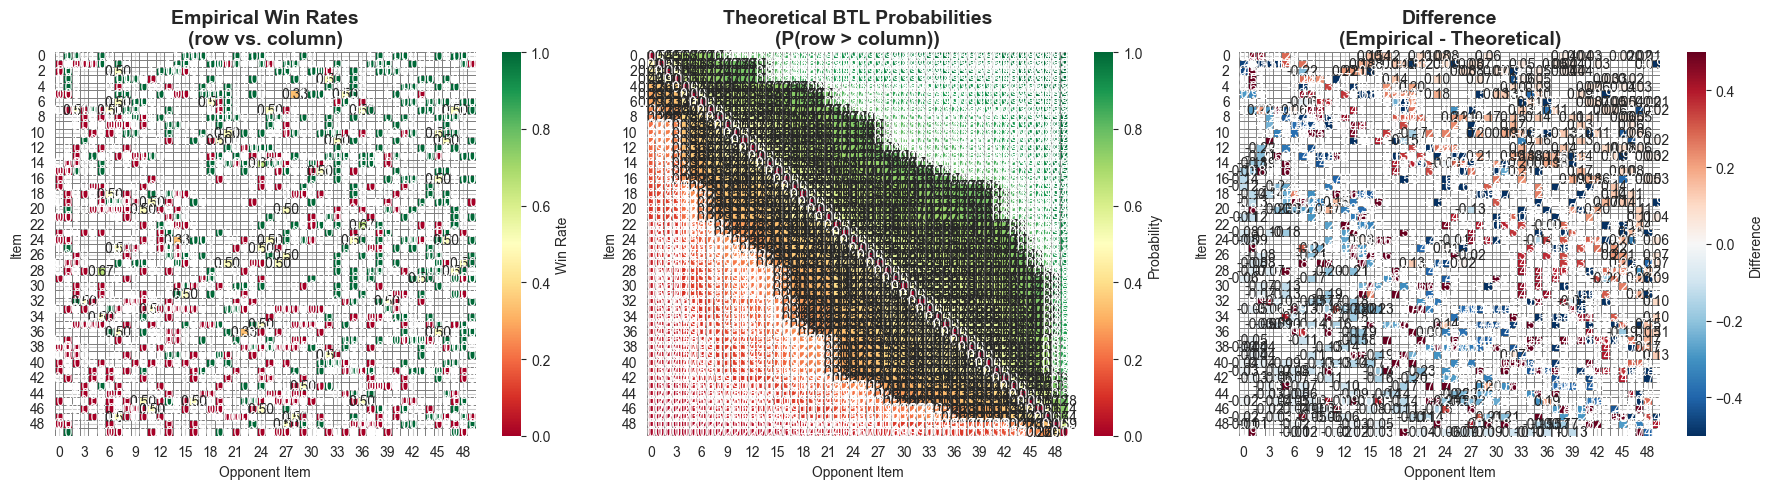


Mean absolute error: 0.343
Comparisons per pair: 0.4 (average)


In [41]:
# Create win rate matrix
win_rate_matrix = np.full((N_ITEMS_VIZ, N_ITEMS_VIZ), np.nan)

# Fill in empirical win rates
for (i, j), outcomes in comp_data.comparisons.items():
    wins_i = sum(1 for o in outcomes if o == 1)
    total = len(outcomes)
    win_rate_matrix[i, j] = wins_i / total if total > 0 else np.nan
    win_rate_matrix[j, i] = 1 - (wins_i / total) if total > 0 else np.nan

# Compute theoretical BTL probabilities
strengths = results_viz['ground_truth_strengths']
theoretical_probs = np.zeros((N_ITEMS_VIZ, N_ITEMS_VIZ))

for i in range(N_ITEMS_VIZ):
    for j in range(N_ITEMS_VIZ):
        if i != j:
            # BTL: P(i > j) = exp(s_i) / (exp(s_i) + exp(s_j))
            theoretical_probs[i, j] = np.exp(strengths[i]) / (np.exp(strengths[i]) + np.exp(strengths[j]))

# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Empirical win rates
sns.heatmap(win_rate_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            vmin=0, vmax=1, cbar_kws={'label': 'Win Rate'}, ax=axes[0], 
            linewidths=0.5, linecolor='gray')
axes[0].set_title('Empirical Win Rates\n(row vs. column)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Opponent Item')
axes[0].set_ylabel('Item')

# Theoretical BTL probabilities
sns.heatmap(theoretical_probs, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            vmin=0, vmax=1, cbar_kws={'label': 'Probability'}, ax=axes[1],
            linewidths=0.5, linecolor='gray')
axes[1].set_title('Theoretical BTL Probabilities\n(P(row > column))', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Opponent Item')
axes[1].set_ylabel('Item')

# Difference (Empirical - Theoretical)
difference = win_rate_matrix - theoretical_probs
sns.heatmap(difference, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, cbar_kws={'label': 'Difference'}, ax=axes[2],
            linewidths=0.5, linecolor='gray')
axes[2].set_title('Difference\n(Empirical - Theoretical)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Opponent Item')
axes[2].set_ylabel('Item')

plt.tight_layout()
plt.show()

print(f"\nMean absolute error: {np.nanmean(np.abs(difference)):.3f}")
print(f"Comparisons per pair: {N_COMPARISONS_VIZ / (N_ITEMS_VIZ * (N_ITEMS_VIZ - 1) / 2):.1f} (average)")

## 5. Quick Sanity Check: Perfect Ranking with Enough Data

With enough comparisons and low noise, we should recover the true ranking perfectly.

In [42]:
# Small problem with lots of data
N_ITEMS = 100
MAX_COMPARISONS = N_ITEMS * (N_ITEMS - 1) // 2  # All possible pairs

# Very low noise
noise_model = noise.BetaNoiseModel(mu=0.05, phi=50.0)  # 5% error, low variance

runner = simulation.SimulationRunner(
    n_items=N_ITEMS,
    noise_model=noise_model,
    ranker=ranking.BordaCountRanker(),
    sampling_strategy=sampling.RandomSampling(allow_repeats=False)
)

results = runner.run_trial(
    n_comparisons=MAX_COMPARISONS,
    random_state=42
)

print("="*60)
print("SANITY CHECK: Low Noise + Full Data")
print("="*60)
print(f"Items: {N_ITEMS}")
print(f"Comparisons: {MAX_COMPARISONS} (all possible pairs)")
print(f"Noise: Beta(mu=0.05, phi=50) - very low error")
print()
print(f"True ranking:      {results['true_ranking']}")
print(f"Estimated ranking: {results['estimated_ranking']}")
print()
print(f"Perfect match: {results['true_ranking'] == results['estimated_ranking']}")
print(f"Kendall distance: {results['kendall_distance']}")
print(f"Rank Correlation: {results['rank_correlation']}")

print("="*60)

SANITY CHECK: Low Noise + Full Data
Items: 100
Comparisons: 4950 (all possible pairs)
Noise: Beta(mu=0.05, phi=50) - very low error

True ranking:      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Estimated ranking: [4, 6, 0, 5, 1, 3, 2, 8, 10, 7, 15, 9, 21, 16, 11, 23, 18, 14, 13, 24, 38, 12, 36, 17, 32, 29, 26, 35, 25, 33, 20, 39, 30, 27, 19, 37, 34, 31, 51, 46, 28, 48, 45, 47, 22, 74, 44, 42, 69, 43, 41, 60, 52, 58, 50, 72, 55, 53, 79, 56, 40, 76, 62, 70, 68, 66, 63, 49, 78, 61, 57, 73, 59, 83, 71, 64, 80, 77, 54, 75, 88, 67, 65, 86, 87, 90, 84, 91, 81, 92, 82, 85, 89, 98, 96, 95, 97, 99, 93, 94]

Perfect match: False
Kendall distance: 474
Ran